# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import math

from scipy.optimize import curve_fit
from statistics import mean
from scipy.integrate import quad
from sklearn.metrics import r2_score
from collections import Counter

# Set Paths

In [2]:
catalog_dir = "/home/alab_student/Tim/Projects/Catalogs/"
outdir = "/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/"

# Parameters

In [3]:
c = 3 * (10 ** 5) # km/s
H_0 = 73 # km/s
omega_m = 0.3

labels = ['FSRQ', 'BLL', 'BCU']
colors = ['blue', 'red', 'purple']

# Functions

In [4]:
def mask_catalog_by_class(catalog, class_column):
    fsrq_mask = [x in ['FSRQ','fsrq'] for x in catalog[class_column].tolist()]
    bll_mask = [x in ['BLL','bll'] for x in catalog[class_column].tolist()]
    bcu_mask = [x in ['BCU','bcu'] for x in catalog[class_column].tolist()]

    fsrq_masked_catalog = catalog[fsrq_mask]
    bll_masked_catalog = catalog[bll_mask]
    bcu_masked_catalog = catalog[bcu_mask]

    return fsrq_masked_catalog, bll_masked_catalog, bcu_masked_catalog

def line(x_data,m,c): 
    return m*x_data + c 


def split_into_n_bins(lst, n_bins):
    sorted_lst = sorted(lst)  # optional, if bins should be ordered
    k, m = divmod(len(sorted_lst), n_bins)
    bins = [sorted_lst[i * k + min(i, m):(i + 1) * k + min(i + 1, m)] for i in range(n_bins)]
    return bins

def make_bin_bounds(list, n_bins):
    binned_redshifts = split_into_n_bins(list, n_bins)

    bin_bounds = []
    for i in range(len(binned_redshifts)):
        bound = binned_redshifts[i][0]
        bin_bounds.append(bound)
        
    bin_bounds.append(binned_redshifts[len(binned_redshifts) - 1][len(binned_redshifts[(len(binned_redshifts) - 1)]) -1])

    return bin_bounds
def blazar_color_scheme(Class):
    if Class == 'fsrq' or Class == 'FSRQ':
        color = 'blue'
        label = 'fsrq'
    if Class == 'BLL' or Class == 'bll':
        color = 'red'
        label = 'bll'
    if Class == 'BCU' or Class == 'bcu':
        color = 'purple'
        label = 'bcu'

    return color 

def exponential(x, A, B):
    return A * np.exp(B * x)

def Luminosity_distance(z):
    def f(x):
        return 1 / np.sqrt(omega_m * (x**3) + 1 - omega_m)

    integral, _ = quad(f, 1, 1 + z)
    return (1 + z) * (c / H_0) * integral 


def luminosity(z, d_L, gamma, gamma_err, flux, flux_err):

    L = 4 * math.pi * d_L**2 * (1 + z)**(gamma - 2) * flux * 9.52e48

    rel_err_gamma = (np.log(1 + z) * gamma_err)**2
    rel_err_flux = (flux_err / flux)**2

    # Total error
    L_err = L * np.sqrt(rel_err_gamma + rel_err_flux)
    
    return L, L_err

def make_bin_bounds(list, n_bins):
    binned_redshifts = split_into_n_bins(list, n_bins)

    bin_bounds = []
    for i in range(len(binned_redshifts)):
        bound = binned_redshifts[i][0]
        bin_bounds.append(bound)
        
    bin_bounds.append(binned_redshifts[len(binned_redshifts) - 1][len(binned_redshifts[(len(binned_redshifts) - 1)]) -1])

    return bin_bounds


def weighted_avg_and_err(values, errors):
    values = np.array(values)
    errors = np.array(errors)

    valid_mask = errors > 0
    values = values[valid_mask]
    errors = errors[valid_mask]

    weights = 1 / errors**2
    weighted_avg = np.sum(values * weights) / np.sum(weights)
    weighted_err = np.sqrt(1 / np.sum(weights))
    
    return weighted_avg, weighted_err

# Catalogs

In [5]:
Flux_Fitting_Results = Table.read(catalog_dir + 'MeV_Blazar_Flux_Fits_All_results.fits')

Fermi_Joined_catalog = Table.read(catalog_dir + 'Fermi_JOINED_catalog.fits')

SED_Fitting_results = Table.read(catalog_dir + 'MeV_Blazar_Fits_All_results.fits')

MeV_Blazar_Catalog = Table.read(catalog_dir + 'MeV_Blazar_Catalog_v2.fits')

Modeled_Fitting_results = Table.read(catalog_dir + 'Modeled_MeV_Blazar_flux.fits')

LAT_data = Table.read(catalog_dir + 'LAT_peaks_data.fits')

Masked_LAT_data = Table.read(catalog_dir + 'Masked_LAT_results.fits')

LAT_BH_Catalog = Table.read(catalog_dir + 'LAT_DR2_BHs.fits')

Masked_SED_fit_results = Table.read(catalog_dir + 'Masked_SED_fit_results.fits')

Masked_Flux_fitting_results = Table.read(catalog_dir + 'Masked_Flux_fitting_results.fits')

Fermi_LAC_DR3 = Table.read(catalog_dir + 'Fermi_LAC_DR3.fits')

LP_Flux_fitting_results = Table.read(catalog_dir + 'MeV_Blazar_Flux_Fits_results_LP.fits')

PL_Flux_fitting_results = Table.read(catalog_dir + 'MeV_Blazar_Flux_Fits_results_PL.fits')

Fermi_LAT_DR4 = Table.read(catalog_dir + '4FGLDR4.fit')


In [6]:
MeV_Blazar_Catalog.pprint_all()

 id Match Flag  Fermi Counterpart Name   Swift Counterpart Name   Fermi Type    Swift Type   SED Class      Fermi RA           Fermi DEC      Swift RA Swift DEC    Fermi Redshift    Swift Redshift Fermi Photon Index Fermi Photon Index Err Swift Photon Index Swift Photon Index Err Log Swift Luminosity    Syn Peak Energy         Syn Peak Flux                        Energy                                    Energy Flux                                    Energy Flux Err                
                                                                                                              deg                 deg           deg       deg                                                                                                                                  erg / s                 MeV               MeV / (s cm2)                         MeV                                     MeV / (s cm2)                                    MeV / (s cm2)                 
--- ---------- -----------

# Make Matched-Joined Catalog

In [7]:
Matched_masses = []
Matched_mass_errors = []

for i in range(len(Masked_SED_fit_results)): 
    Match_mask = (Masked_SED_fit_results[i]['Name'] == LAT_BH_Catalog['ASSOC_Name'])
    
    if any(Match_mask): 
        Mass = LAT_BH_Catalog[Match_mask]['BH_Mass'].tolist()[0]
        Mass_err = LAT_BH_Catalog[Match_mask]['BH_Mass_err'].tolist()[0]
        Matched_masses.append(Mass)
        Matched_mass_errors.append(Mass_err)
    else:
        Mass = 'None'
        Mass_err = 'None'
        Matched_masses.append(Mass)
        Matched_mass_errors.append(Mass_err)

print(len(Matched_masses))

masked_names = Masked_Flux_fitting_results['Name'].tolist()
MeV_Blazar_mask = [x in masked_names for x in MeV_Blazar_Catalog['Fermi Counterpart Name'].tolist()]
Masked_MeV_Blazar_Catalog = MeV_Blazar_Catalog[MeV_Blazar_mask]
Masked_MeV_Blazar_Catalog.write(catalog_dir + 'MeV_Blazar_Catalog_MASKED.fits', overwrite=True)

Matched_Redshifts = []

for i in range(len(Masked_MeV_Blazar_Catalog)):
    Fermi_redshift = Masked_MeV_Blazar_Catalog[i]['Fermi Redshift']
    Swift_redshift = Masked_MeV_Blazar_Catalog[i]['Swift Redshift']

    if Fermi_redshift != 'None':
        Matched_Redshifts.append(Fermi_redshift)
    elif Fermi_redshift == 'None' and Swift_redshift != 'None':
        Matched_Redshifts.append(Swift_redshift)
    elif Fermi_redshift == 'None' and Swift_redshift == 'None':
        Matched_Redshifts.append('None')

Matched_Luminosities = []
Matched_Luminosity_error = []

for i in range(len(Masked_Flux_fitting_results)):
    Index = Masked_Flux_fitting_results[i]['Index'].tolist()
    Redshift = Matched_Redshifts[i]
    Flux = Masked_Flux_fitting_results[i]['Energy_Flux'].tolist()
    
    Index_err = Masked_Flux_fitting_results[i]['Index_Err'].tolist()
    Flux_err = Masked_Flux_fitting_results[i]['Energy_Flux_Err'].tolist()

    if Redshift != 'None':
        Redshift = float(Redshift)
        Luminosity, Luminosity_err = luminosity(Redshift, Luminosity_distance(Redshift), Index, Index_err, Flux, Flux_err)
        Matched_Luminosities.append(np.log10(Luminosity))
        Matched_Luminosity_error.append((1/np.log(10)) * (Luminosity_err/Luminosity))
    
    else:
        Matched_Luminosities.append('None')
        Matched_Luminosity_error.append('None')

Matched_GeV_Flux = []
Matched_GeV_Flux_err = []

for i in range(len(Masked_Flux_fitting_results)):
    Match_mask = (Masked_Flux_fitting_results[i]['Name'] == Masked_LAT_data['Assoc_Name'])

    if any(Match_mask):
        Energy_Flux_GeV = Masked_LAT_data[Match_mask]['Energy_Flux_GeV'].tolist()[0]
        Energy_Flux_GeV_err = Masked_LAT_data[Match_mask]['Energy_Flux_Err_GeV'].tolist()[0]
        Matched_GeV_Flux.append(Energy_Flux_GeV)
        Matched_GeV_Flux_err.append(Energy_Flux_GeV_err)

    else:
        Matched_GeV_Flux.append('None')
        Matched_GeV_Flux_err.append('None') 
  

Masked_matched_names = [x.ljust(28) for x in Masked_Flux_fitting_results['Name'].tolist()]
name_mask = [x in Masked_matched_names for x in Fermi_LAT_DR4['ASSOC1'].tolist()]

Fermi_LAT_DR4_masked = Fermi_LAT_DR4[name_mask]
Fermi_LAT_DR4_masked.write(catalog_dir + 'Fermi_LAT_DR4_masked.fits', overwrite=True)
Fermi_LAT_DR4_masked.pprint_all()

Matched_LAT_LP_Index = []
Matched_LAT_LP_Index_err = []

for i in range(len(Fermi_LAT_DR4_masked)):
    Match_mask = (Masked_Flux_fitting_results[i]['Name'].ljust(28) == Fermi_LAT_DR4_masked['ASSOC1'])

    if any(Match_mask):

        LP_Index = Fermi_LAT_DR4_masked[Match_mask]['LP_Index'].tolist()[0]
        LP_Index_err = Fermi_LAT_DR4_masked[Match_mask]['Unc_LP_Index'].tolist()[0]
        Matched_LAT_LP_Index.append(LP_Index)
        Matched_LAT_LP_Index_err.append(LP_Index_err)

    else:
        Matched_LAT_LP_Index.append('None')
        Matched_LAT_LP_Index_err.append('None')  

78
   Source_Name     DataRelease RAJ2000  DEJ2000    GLON     GLAT   Conf_68_SemiMajor Conf_68_SemiMinor Conf_68_PosAng Conf_95_SemiMajor Conf_95_SemiMinor Conf_95_PosAng ROI_num Extended_Source_Name Signif_Avg Pivot_Energy   Flux1000   Unc_Flux1000 Energy_Flux100 Unc_Energy_Flux100    SpectrumType   PL_Flux_Density  Unc_PL_Flux_Density PL_Index Unc_PL_Index LP_Flux_Density  Unc_LP_Flux_Density LP_Index Unc_LP_Index LP_beta  Unc_LP_beta LP_SigCurv  LP_EPeak  Unc_LP_EPeak PLEC_Flux_Density Unc_PLEC_Flux_Density PLEC_IndexS Unc_PLEC_IndexS PLEC_ExpfactorS Unc_PLEC_ExpfactorS PLEC_Exp_Index Unc_PLEC_Exp_Index PLEC_SigCurv PLEC_EPeak Unc_PLEC_EPeak   Npred               Flux_Band                     Unc_Flux_Band                     nuFnu_Band                 Sqrt_TS_Band      Variability_Index Frac_Variability Unc_Frac_Variability Signif_Peak   Flux_Peak    Unc_Flux_Peak   Time_Peak  Peak_Interval           Flux_History                  Unc_Flux_History            Sqrt_TS_History        

In [8]:
Matched_names = Masked_Flux_fitting_results['Name'].tolist()
Matched_class = Masked_Flux_fitting_results['Class'].tolist()
Matched_energy_flux = Masked_Flux_fitting_results['Energy_Flux'].tolist()
Matched_energy_flux_err = Masked_Flux_fitting_results['Energy_Flux_Err'].tolist()
Matched_index = Masked_Flux_fitting_results['Index'].tolist()
Matched_index_err = Masked_Flux_fitting_results['Index_Err'].tolist()
Matched_IC_peak = Masked_SED_fit_results['IC_Peak_Energy'].tolist()
Matched_IC_peak_err = Masked_SED_fit_results['IC_Peak_Energy_Err'].tolist()
Matched_IC_peak_flux = Masked_SED_fit_results['IC_Peak_Energy_Flux'].tolist()
Matched_LAT_index = Masked_MeV_Blazar_Catalog['Fermi Photon Index'].tolist()
Matched_LAT_index_err = Masked_MeV_Blazar_Catalog['Fermi Photon Index Err'].tolist()
Matched_SED_class = Masked_MeV_Blazar_Catalog['SED Class'].tolist()
Matched_alpha = Masked_SED_fit_results['Alpha'].tolist()
Matched_alpha_err = Masked_SED_fit_results['Alpha_Err'].tolist()
Matched_beta = Masked_SED_fit_results['Beta'].tolist()
Matched_beta_err = Masked_SED_fit_results['Beta_Err'].tolist()

Matched_JOINED_Catalog = Table([Matched_names, Matched_class, Matched_SED_class, Matched_Redshifts, Matched_index, Matched_index_err, Matched_alpha, Matched_alpha_err, Matched_beta, Matched_beta_err, Matched_LAT_index, Matched_LAT_index_err, Matched_LAT_LP_Index, Matched_LAT_LP_Index_err, Matched_IC_peak, Matched_IC_peak_err, Matched_IC_peak_flux, Matched_energy_flux, Matched_energy_flux_err, Matched_GeV_Flux, Matched_GeV_Flux_err, Matched_Luminosities,Matched_Luminosity_error, Matched_masses, Matched_mass_errors], names=['Name', 'Class', 'SED_Class','Redshift','MeV_Index','MeV_Index_err','Alpha','Alpha_err','Beta','Beta_err','LAT_PL_Index','LAT_PL_Index_err','LAT_LP_Index','LAT_LP_Index_err','IC_Peak_Energy','IC_Peak_Energy_err','IC_Peak_Flux','MeV_Energy_Flux','MeV_Energy_Flux_err','GeV_Energy_Flux','GeV_Energy_Flux_err','Luminosity','Luminosity_err','BH_Mass','BH_Mass_err'])
Matched_JOINED_Catalog.write(catalog_dir + 'MeV_Blazar_JOINED_Catalog.fits', overwrite=True)

In [9]:
Matched_JOINED_Catalog.pprint_all()

Matched_JOINED_FSRQ, Matched_JOINED_BLL, Matched_JOINED_BCU = mask_catalog_by_class(Matched_JOINED_Catalog, 'Class')
Matched_JOINED_all = [Matched_JOINED_FSRQ, Matched_JOINED_BLL, Matched_JOINED_BCU]

          Name          Class SED_Class       Redshift          MeV_Index          MeV_Index_err           Alpha              Alpha_err               Beta                Beta_err          LAT_PL_Index       LAT_PL_Index_err      LAT_LP_Index      LAT_LP_Index_err      IC_Peak_Energy    IC_Peak_Energy_err      IC_Peak_Flux         MeV_Energy_Flux      MeV_Energy_Flux_err      GeV_Energy_Flux      GeV_Energy_Flux_err       Luminosity         Luminosity_err    BH_Mass BH_Mass_err
----------------------- ----- --------- ------------------- ------------------ --------------------- ------------------ --------------------- -------------------- --------------------- ------------------ --------------------- ------------------ -------------------- ------------------- ------------------- ---------------------- ---------------------- ---------------------- ---------------------- ---------------------- ------------------ --------------------- ------- -----------
            B2 0135+291   bcu       

# Catalog Analysis

78
[-2.7385833   7.77560636]


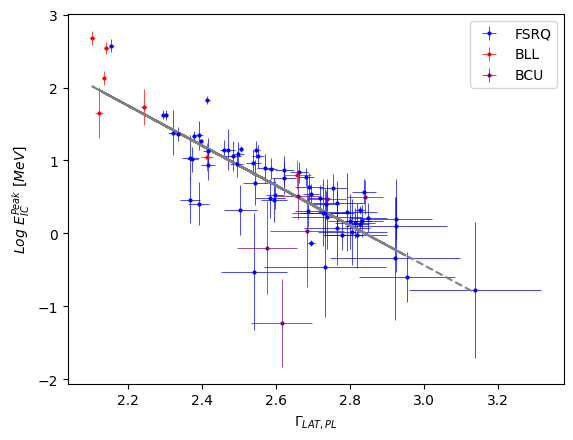

In [10]:
IC_peak_energy_log_all = np.array([np.log10(float(x)) for x in Matched_JOINED_Catalog['IC_Peak_Energy'].tolist()])
LAT_gamma_all = np.array(Matched_JOINED_Catalog['LAT_PL_Index'].tolist())
print(len(LAT_gamma_all))

for i in range(len(Matched_JOINED_all)):
    LAT_gammas = Matched_JOINED_all[i]['LAT_PL_Index'].tolist()
    LAT_gammas_err = [float(x) for x in Matched_JOINED_all[i]['LAT_PL_Index_err'].tolist()]

    IC_peak_energy = [float(x) for x in Matched_JOINED_all[i]['IC_Peak_Energy'].tolist()]
    IC_peak_energy_log = [np.log10(float(x)) for x in IC_peak_energy]
    IC_peak_energy_err = [(float(x)) for x in Matched_JOINED_all[i]['IC_Peak_Energy_err'].tolist()]
    IC_peak_energy_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(IC_peak_energy_err, IC_peak_energy)]

    plt.errorbar(LAT_gammas,IC_peak_energy_log,xerr=LAT_gammas_err,yerr=IC_peak_energy_err_log,fmt='o',markersize=2,elinewidth=0.5,color=colors[i],label=labels[i])
    plt.xlabel(r'$\Gamma_{LAT, PL}$')
    plt.ylabel(r'$Log$ $E^{Peak}_{IC}$ $[MeV]$')
    plt.legend()
    
popt,pcov = curve_fit(line,LAT_gamma_all,IC_peak_energy_log_all, p0=[2,4])
print(popt)
plt.plot(LAT_gamma_all, line(LAT_gamma_all,*popt), color = 'grey', linestyle = '--')

plt.savefig(outdir + 'IC_Peak_Linear_regression.png', bbox_inches='tight')

[-2.30345763  6.58460497]


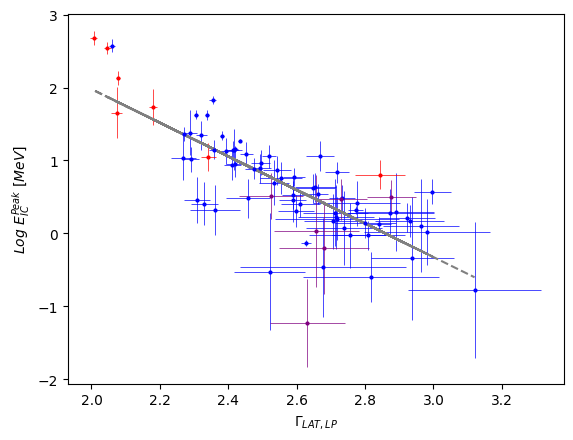

In [11]:
LAT_LP_gamma_all = np.array(Matched_JOINED_Catalog['LAT_LP_Index'].tolist())

for i in range(len(Matched_JOINED_all)):

    LAT_gammas = Matched_JOINED_all[i]['LAT_LP_Index'].tolist()
    LAT_gammas_err = [float(x) for x in Matched_JOINED_all[i]['LAT_LP_Index_err'].tolist()]

    IC_peak_energy = [float(x) for x in Matched_JOINED_all[i]['IC_Peak_Energy'].tolist()]
    IC_peak_energy_log = [np.log10(float(x)) for x in IC_peak_energy]
    IC_peak_energy_err = [(float(x)) for x in Matched_JOINED_all[i]['IC_Peak_Energy_err'].tolist()]
    IC_peak_energy_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(IC_peak_energy_err, IC_peak_energy)]

    plt.errorbar(LAT_gammas,IC_peak_energy_log,xerr=LAT_gammas_err,yerr=IC_peak_energy_err_log,fmt='o',markersize=2,elinewidth=0.5,color=colors[i],label=labels[i])
    plt.xlabel(r'$\Gamma_{LAT,LP}$')
    plt.ylabel(r'$Log$ $E^{Peak}_{IC}$ $[MeV]$')

popt,pcov = curve_fit(line,LAT_LP_gamma_all,IC_peak_energy_log_all, p0=[2,4])
print(popt)
plt.plot(LAT_LP_gamma_all, line(LAT_LP_gamma_all,*popt), color = 'grey', linestyle = '--')

plt.savefig(outdir + 'IC_peak_LP_gamma_regression.png', bbox_inches='tight')

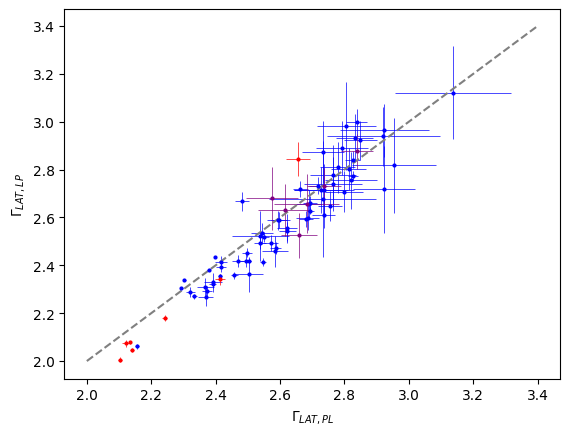

In [12]:
for i in range(len(Matched_JOINED_all)):
    PL_index = Matched_JOINED_all[i]['LAT_PL_Index'].tolist()
    PL_index_err = [float(x) for x in Matched_JOINED_all[i]['LAT_PL_Index_err'].tolist()]

    LP_index = Matched_JOINED_all[i]['LAT_LP_Index'].tolist()
    LP_index_err = [float(x) for x in Matched_JOINED_all[i]['LAT_LP_Index_err'].tolist()]
    plt.ylabel(r'$\Gamma_{LAT,LP}$')
    plt.xlabel(r'$\Gamma_{LAT, PL}$')

    plt.errorbar(PL_index,LP_index,xerr=PL_index_err,yerr=LP_index_err,fmt='o',markersize=2,elinewidth=0.5,color=colors[i],label=labels[i])

x = np.linspace(2, 3.4, 100)
y = x
plt.plot(x, y, linestyle='--', color='grey', label='y = x')

plt.savefig(outdir + 'PL_vs_LP_index.png', bbox_inches='tight')



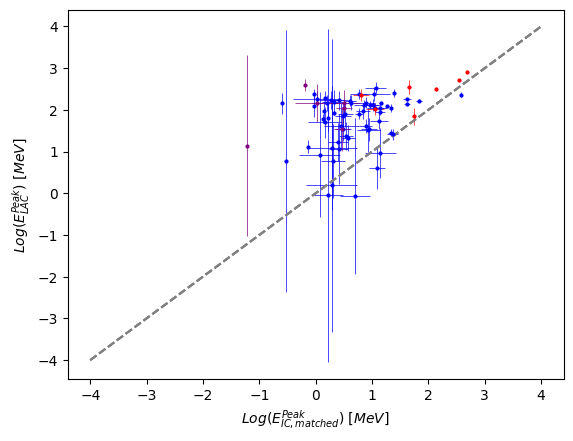

In [13]:
Fermi_LAC_FSRQ, Fermi_LAC_BLL, Fermi_LAC_BCU = mask_catalog_by_class(Fermi_LAC_DR3, 'CLASS')
Fermi_LAC_all = [Fermi_LAC_FSRQ, Fermi_LAC_BLL, Fermi_LAC_BCU]

for i in range(len(Matched_JOINED_all)):

    IC_peak_list = []
    IC_peak_err_list = []
    HE_peak_list = []
    HE_peak_err_list = []

    for x in range(len(Matched_JOINED_all[i])):
        mask = (Matched_JOINED_all[i][x]['Name'] == Fermi_LAC_all[i]['ASSOC1'])
        if any(mask):

            IC_peak_energy = float(Matched_JOINED_all[i][x]['IC_Peak_Energy'].tolist())
            IC_peak_energy_log = np.log10(float(IC_peak_energy))
            IC_peak_energy_err = float(Matched_JOINED_all[i][x]['IC_Peak_Energy_err'].tolist()[0])
            IC_peak_energy_err_log = abs((1/np.log(10)) * (IC_peak_energy_err/IC_peak_energy))

            HE_peak_LAC = Fermi_LAC_all[i][mask]['HE_EPeak'].tolist()[0]
            HE_peak_err_LAC = Fermi_LAC_all[i][mask]['Unc_HE_EPeak'].tolist()[0]

            if HE_peak_LAC != None:
                HE_peak_LAC_log = np.log10(float(HE_peak_LAC))
                HE_peak_err_LAC_log  = abs((1/np.log(10)) * (HE_peak_err_LAC/HE_peak_LAC))

                IC_peak_list.append(IC_peak_energy_log)
                IC_peak_err_list.append(IC_peak_energy_err_log)
                HE_peak_list.append(HE_peak_LAC_log)
                HE_peak_err_list.append(HE_peak_err_LAC_log)

    plt.errorbar(IC_peak_list, HE_peak_list, xerr=IC_peak_err_list, yerr=HE_peak_err_list, fmt='o', markersize=2, elinewidth=0.5, color=colors[i], label=labels[i])
    plt.xlabel(r'$Log(E^{Peak}_{IC, matched})$ $[MeV]$')
    plt.ylabel(r'$Log(E^{Peak}_{LAC})$ $[MeV]$')

    x = np.linspace(-4, 4, 100)
    y = x
    plt.plot(x, y, linestyle='--', color='grey', label='y = x')

plt.savefig(outdir + 'Matched_vs_LAC_Epeaks.png',bbox_inches='tight')

[0.41522367 1.09766654]
[0.02063734 0.05367333]


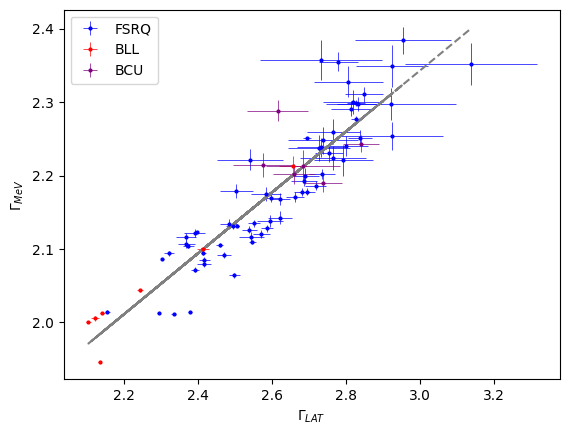

In [14]:
LAT_gammas_all = np.array(Matched_JOINED_Catalog['LAT_PL_Index'].tolist())
MeV_gammas_all = np.array(Matched_JOINED_Catalog['MeV_Index'].tolist())

for i in range(len(Matched_JOINED_all)):
    LAT_gammas = Matched_JOINED_all[i]['LAT_PL_Index'].tolist()
    LAT_gammas_err = [float(x) for x in Matched_JOINED_all[i]['LAT_PL_Index_err'].tolist()]
    MeV_gammas = [float(x) for x in Matched_JOINED_all[i]['MeV_Index'].tolist()]
    MeV_gammas_err = [float(x) for x in Matched_JOINED_all[i]['MeV_Index_err'].tolist()]

    plt.errorbar(LAT_gammas,MeV_gammas,xerr=LAT_gammas_err,yerr=MeV_gammas_err,fmt='o',markersize=2,elinewidth=0.5,color=colors[i],label=labels[i])
    plt.ylabel(r'$\Gamma_{MeV}$')
    plt.xlabel(r'$\Gamma_{LAT}$')
    plt.legend()

popt,pcov = curve_fit(line,LAT_gammas_all,MeV_gammas_all, p0=[2,2])
plt.plot(LAT_gammas_all, line(LAT_gammas_all,*popt), color = 'grey', linestyle = '--')
print(popt)
perr = np.sqrt(np.diag(pcov))
print(perr)
Gamma_slope = popt[0]
Gamma_intercept = popt[1]

plt.savefig(outdir + 'gamma_relationships.png',bbox_inches='tight')

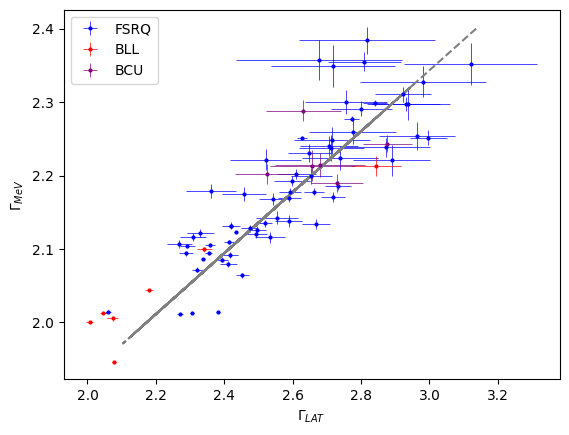

In [15]:
LAT_LP_gammas_all = np.array(Matched_JOINED_Catalog['LAT_PL_Index'].tolist())

for i in range(len(Matched_JOINED_all)):
    LAT_gammas = Matched_JOINED_all[i]['LAT_LP_Index'].tolist()
    LAT_gammas_err = [float(x) for x in Matched_JOINED_all[i]['LAT_LP_Index_err'].tolist()]
    MeV_gammas = [float(x) for x in Matched_JOINED_all[i]['MeV_Index'].tolist()]
    MeV_gammas_err = [float(x) for x in Matched_JOINED_all[i]['MeV_Index_err'].tolist()]

    plt.errorbar(LAT_gammas,MeV_gammas,xerr=LAT_gammas_err,yerr=MeV_gammas_err,fmt='o',markersize=2,elinewidth=0.5,color=colors[i],label=labels[i])
    plt.ylabel(r'$\Gamma_{MeV}$')
    plt.xlabel(r'$\Gamma_{LAT}$')
    plt.legend()

popt,pcov = curve_fit(line,LAT_LP_gammas_all,MeV_gammas_all, p0=[2,2])
plt.plot(LAT_LP_gammas_all, line(LAT_LP_gammas_all,*popt), color = 'grey', linestyle = '--')

[7152.83207022   -9.11866316]
0.4436745607115693


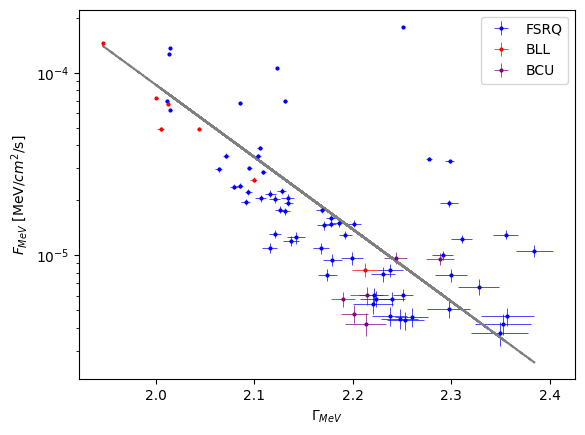

In [16]:
Masked_MeV_gamma_all = np.array(Matched_JOINED_Catalog['MeV_Index'].tolist())
Masked_MeV_flux_all = np.array(Matched_JOINED_Catalog['MeV_Energy_Flux'].tolist())

for i in range(len(Matched_JOINED_all)):
    MeV_gammas = Matched_JOINED_all[i]['MeV_Index'].tolist()
    MeV_gammas_err = Matched_JOINED_all[i]['MeV_Index_err'].tolist()
    MeV_flux = Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()
    MeV_flux_err = Matched_JOINED_all[i]['MeV_Energy_Flux_err'].tolist()

    plt.errorbar(MeV_gammas, MeV_flux,xerr=MeV_gammas_err,yerr=MeV_flux_err, markersize=2,fmt='o',color=colors[i],label=labels[i],elinewidth=0.5)
    plt.yscale('log')
    plt.xlabel(r'$\Gamma_{MeV}$')
    plt.ylabel(r'$F_{MeV}$ [MeV/$cm^{2}$/s]')
    plt.legend()

popt,pcov = curve_fit(exponential,Masked_MeV_gamma_all,Masked_MeV_flux_all, p0=[76000, -10])
print(popt)

Flux_intercept2 = popt[0]
Flux_slope2 = popt[1]

r2_masked = r2_score(Masked_MeV_flux_all, exponential(Masked_MeV_gamma_all,*popt))
print(r2_masked)

plt.plot(Masked_MeV_gamma_all, exponential(Masked_MeV_gamma_all,*popt), color = 'grey', linestyle = '--')
plt.legend()

plt.savefig(outdir + 'Masked_results_Flux_steepness.png', bbox_inches='tight')

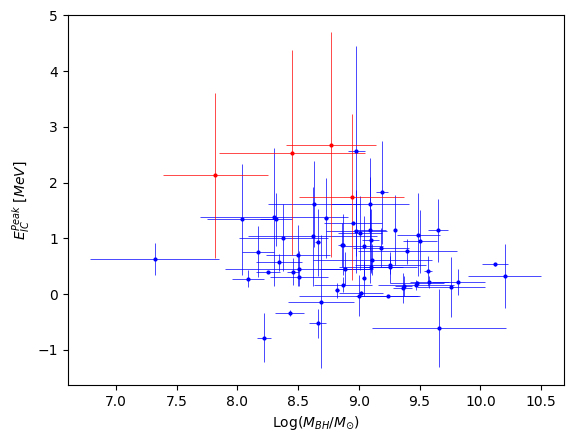

In [17]:
for i in range(len(Matched_JOINED_all)):
    Mass = Matched_JOINED_all[i]['BH_Mass'].tolist()
    Mass_err = Matched_JOINED_all[i]['BH_Mass_err'].tolist()
    Peak_Energy = Matched_JOINED_all[i]['IC_Peak_Energy'].tolist()
    Peak_Energy_err = Matched_JOINED_all[i]['IC_Peak_Energy_err'].tolist()

    masked_results = [(float(a),float(b),np.log10(float(c)),abs(np.log10(float(d)))) for a,b,c,d in zip(Mass,Mass_err,Peak_Energy,Peak_Energy_err) if a != 'None']

    if len(masked_results) != 0:

        masked_mass, masked_mass_err, masked_peak_E, masked_peak_E_err = zip(*masked_results)

        masked_mass = list(masked_mass)
        masked_mass_err = list(masked_mass_err)
        masked_peak_E = list(masked_peak_E)
        masked_peak_E_err = list(masked_peak_E_err)

        plt.errorbar(masked_mass,masked_peak_E,xerr=masked_mass_err,yerr=masked_peak_E_err,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
        plt.xlabel(r'Log($M_{BH}$/$M_{\odot}$)')
        plt.ylabel(r'$E^{Peak}_{IC}$ $[MeV]$')

[1.0313152411571882, 2.6037926625820473, 0.7250421472247512, 0.6247601724142314, 2.6444850402059807, 2.105348836208666, 2.7667282861906415, 0.7184735983532167, 1.2940652483567099, 2.3381320694146, 2.200926336408558, 2.078927555593476, 0.5109545437707866, 1.381424129966627, 1.5959967853238688, 0.5748202412235754, 0.6597092999093427, 1.0424518010176282, -1.1803898839641467, 1.292718089253716, 1.1483061953645344, 0.3483030738491726, 0.25555463925994903, 0.5413370988612513, 4.4436366576666355, 0.7857903823952257, 1.96011068475503, -0.15236349952753997, 0.1327898508154028, 2.4960401733609996, 3.044993666398082, 1.5946908942962532, 0.4908728388780001, 1.8230677580039039, 1.6170511087507744, 5.141728496137727, 1.4837118332471089, 0.5730418894353281, 0.6192611878755515, 1.9824141364321024, 1.3241695474919504, 2.414555178384872, 0.43261339263856097, 2.2253946659296466, 1.2110481903135653, 2.2653546280197574, 3.29980427121345, 2.3611241528933316, 1.363629112757181, -0.05579809303036208, 2.735125

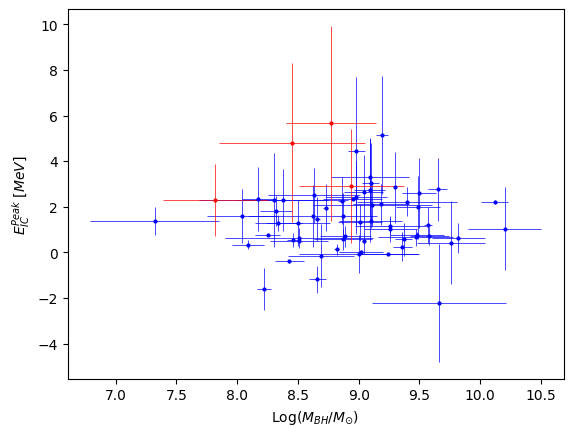

In [18]:
for i in range(len(Matched_JOINED_all)):
    Mass = Matched_JOINED_all[i]['BH_Mass'].tolist()
    Mass_err = Matched_JOINED_all[i]['BH_Mass_err'].tolist()
    Peak_Energy = Matched_JOINED_all[i]['IC_Peak_Energy'].tolist()
    Peak_Energy_err = Matched_JOINED_all[i]['IC_Peak_Energy_err'].tolist()
    redshift = Matched_JOINED_all[i]['Redshift'].tolist()

    masked_results = [(float(a),float(b),np.log10(float(c)),abs(np.log10(float(d))), float(e)) for a,b,c,d,e in zip(Mass,Mass_err,Peak_Energy,Peak_Energy_err,redshift) if a != 'None']

    if len(masked_results) != 0:

        masked_mass, masked_mass_err, masked_peak_E, masked_peak_E_err,masked_redshift = zip(*masked_results)

        masked_mass = list(masked_mass)
        masked_mass_err = list(masked_mass_err)

        masked_peak_E = list(masked_peak_E)
        masked_peak_E_err = list(masked_peak_E_err)
        masked_redshift = list(masked_redshift)

        masked_peak_E_corr= [x * (1+y) for x,y in zip(masked_peak_E, masked_redshift)]
        print(masked_peak_E_corr)
        masked_peak_E_err_corr = [x * (1+y) for x,y in zip(masked_peak_E_err, masked_redshift)]

        plt.errorbar(masked_mass,masked_peak_E_corr,xerr=masked_mass_err,yerr=masked_peak_E_err_corr,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
        plt.xlabel(r'Log($M_{BH}$/$M_{\odot}$)')
        plt.ylabel(r'$E^{Peak}_{IC}$ $[MeV]$')

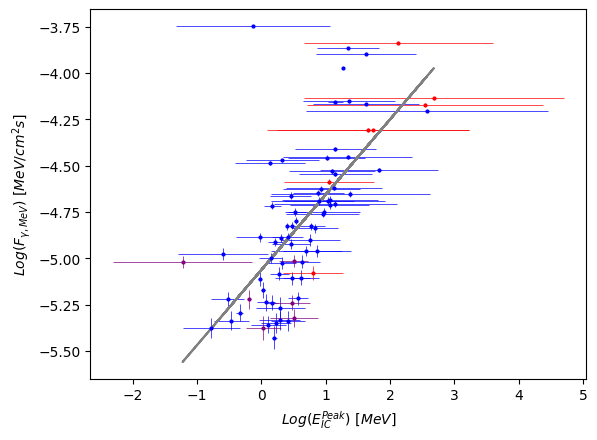

In [19]:
Peak_Energy_all = np.array([np.log10(float(x)) for x in Matched_JOINED_Catalog['IC_Peak_Energy'].tolist()])
Energy_flux_all = np.array([np.log10(x) for x in Matched_JOINED_Catalog['MeV_Energy_Flux'].tolist()])

for i in range(len(Matched_JOINED_all)): 
    Peak_Energy = [np.log10(float(x)) for x in Matched_JOINED_all[i]['IC_Peak_Energy'].tolist()]
    Peak_Energy_err = [abs(np.log10(float(x))) for x in Matched_JOINED_all[i]['IC_Peak_Energy_err'].tolist()]
    Energy_Flux = [np.log10(x) for x in Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()]
    MeV_Flux = Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()
    MeV_Flux_err = Matched_JOINED_all[i]['MeV_Energy_Flux_err'].tolist()
    MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(MeV_Flux_err, MeV_Flux)]

    plt.errorbar(Peak_Energy, Energy_Flux, xerr=Peak_Energy_err,yerr=MeV_Flux_err_log,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(E^{Peak}_{IC})$ $[MeV]$')
    plt.ylabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')

popt,pcov = curve_fit(line,Peak_Energy_all, Energy_flux_all, p0=[1.1, -5.3])
plt.plot(Peak_Energy_all, line(Peak_Energy_all,*popt), color = 'grey', linestyle = '-')

plt.savefig(outdir + 'Flux_peak_Energy_corr.png', bbox_inches='tight')


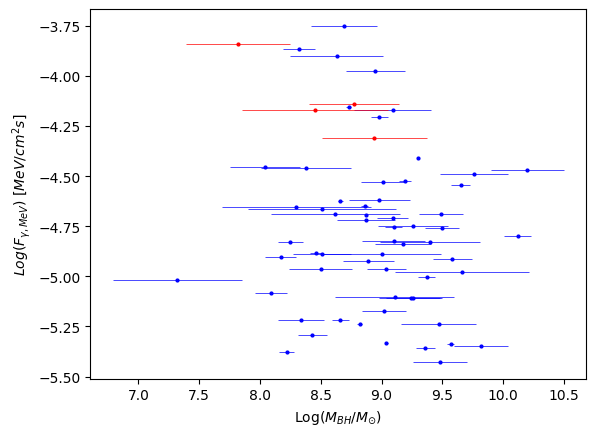

In [20]:
for i in range(len(Matched_JOINED_all)):
    Mass = Matched_JOINED_all[i]['BH_Mass'].tolist()
    Mass_err = Matched_JOINED_all[i]['BH_Mass_err'].tolist()
    Energy_Flux = [np.log10(x) for x in Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()]

    masked_results = [(float(a),float(b),c,) for a,b,c in zip(Mass,Mass_err,Energy_Flux) if a != 'None']

    if len(masked_results) != 0:

        masked_mass, masked_mass_err, masked_flux = zip(*masked_results)

        masked_mass = list(masked_mass)
        masked_mass_err = list(masked_mass_err)
        masked_flux = list(masked_flux)

        plt.errorbar(masked_mass,masked_flux,xerr=masked_mass_err,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
        plt.ylabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')
        plt.xlabel(r'Log($M_{BH}$/$M_{\odot}$)')

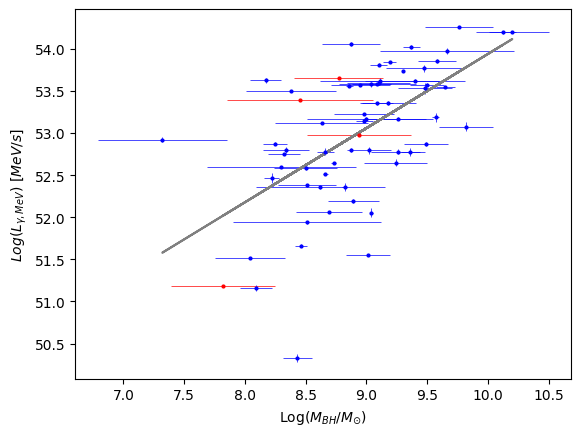

In [21]:
masked_mass_lum = [(float(a),b) for a,b in zip(Matched_JOINED_Catalog['BH_Mass'].tolist(), Matched_JOINED_Catalog['Luminosity'].tolist()) if a != 'None' and b != 'None']
masked_mass_all,masked_luminosity_all = zip(*masked_mass_lum)

masked_luminosity_all = np.array(list(masked_luminosity_all))
masked_mass_all = np.array(list(masked_mass_all))

for i in range(len(Matched_JOINED_all)):
    Mass = Matched_JOINED_all[i]['BH_Mass'].tolist()
    Mass_err = Matched_JOINED_all[i]['BH_Mass_err'].tolist()
    Luminosity = Matched_JOINED_all[i]['Luminosity'].tolist()
    Luminosity_err = Matched_JOINED_all[i]['Luminosity_err'].tolist()

    masked_results = [(float(a),float(b),float(c),float(d)) for a,b,c,d in zip(Mass,Mass_err,Luminosity,Luminosity_err) if a != 'None' and c != 'None']

    if len(masked_results) != 0:

        masked_mass, masked_mass_err, masked_luminosity, masked_luminosity_err = zip(*masked_results)

        masked_mass = list(masked_mass)
        masked_mass_err = list(masked_mass_err)
        masked_luminosity = list(masked_luminosity)
        masked_luminosity_err = list(masked_luminosity_err)

        plt.errorbar(masked_mass,masked_luminosity,xerr=masked_mass_err,yerr=masked_luminosity_err,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
        plt.ylabel(r'$Log(L_{\gamma, MeV})$ $[MeV/s]$')
        plt.xlabel(r'Log($M_{BH}$/$M_{\odot}$)')

popt,pcov = curve_fit(line,masked_mass_all,masked_luminosity_all, p0=[1, 40])
plt.plot(masked_mass_all, line(masked_mass_all,*popt), color = 'grey', linestyle = '-')

plt.savefig(outdir + 'BH_Luminosity_correlation.png',bbox_inches='tight')

[  0.39849756 -12.19014568]


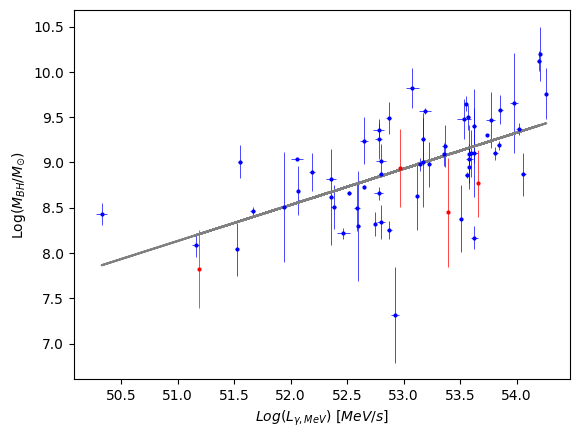

In [22]:
masked_lum_mass = [(float(b), a) for a, b in zip(Matched_JOINED_Catalog['BH_Mass'].tolist(), Matched_JOINED_Catalog['Luminosity'].tolist()) if a != 'None' and b != 'None']
masked_luminosity_all, masked_mass_all = zip(*masked_lum_mass)

masked_luminosity_all = np.array(list(masked_luminosity_all))
masked_mass_all = np.array(list(masked_mass_all))

for i in range(len(Matched_JOINED_all)):
    Mass = Matched_JOINED_all[i]['BH_Mass'].tolist()
    Mass_err = Matched_JOINED_all[i]['BH_Mass_err'].tolist()
    Luminosity = Matched_JOINED_all[i]['Luminosity'].tolist()
    Luminosity_err = Matched_JOINED_all[i]['Luminosity_err'].tolist()

    masked_results = [(float(c), float(d), float(a), float(b)) 
                      for a, b, c, d in zip(Mass, Mass_err, Luminosity, Luminosity_err) 
                      if a != 'None' and c != 'None']

    if len(masked_results) != 0:
        masked_luminosity, masked_luminosity_err, masked_mass, masked_mass_err = zip(*masked_results)

        masked_luminosity = list(masked_luminosity)
        masked_luminosity_err = list(masked_luminosity_err)
        masked_mass = list(masked_mass)
        masked_mass_err = list(masked_mass_err)

        plt.errorbar(masked_luminosity, masked_mass, xerr=masked_luminosity_err, yerr=masked_mass_err,
                     fmt='o', markersize=2, color=colors[i], label=labels[i], elinewidth=0.5)

        plt.xlabel(r'$Log(L_{\gamma, MeV})$ $[MeV/s]$')
        plt.ylabel(r'Log($M_{BH}$/$M_{\odot}$)')

popt, pcov = curve_fit(line, masked_luminosity_all, masked_mass_all, p0=[1, 8])
plt.plot(masked_luminosity_all, line(masked_luminosity_all, *popt), color='grey', linestyle='-')
print(popt)

plt.savefig(outdir + 'BH_Luminosity_correlation2.png', bbox_inches='tight')


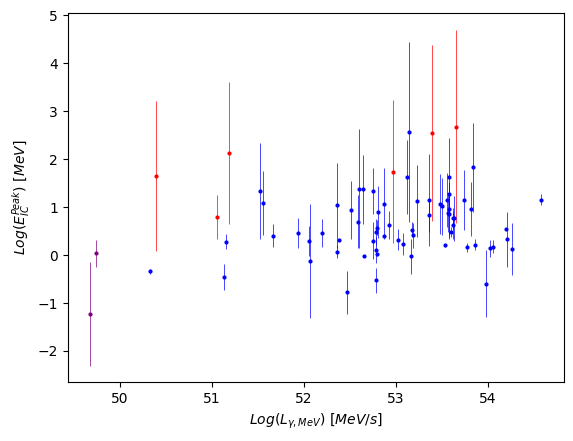

In [23]:
for i in range(len(Matched_JOINED_all)):
    Luminosity = Matched_JOINED_all[i]['Luminosity'].tolist()
    Peak_Energy = [np.log10(float(x)) for x in Matched_JOINED_all[i]['IC_Peak_Energy'].tolist()]
    Peak_Energy_err = [abs(np.log10(float(x))) for x in Matched_JOINED_all[i]['IC_Peak_Energy_err'].tolist()]

    masked_results = [(float(a),b,c) for a,b,c in zip(Luminosity,Peak_Energy,Peak_Energy_err) if a != 'None']

    masked_luminosity, masked_peak_energy, masked_peak_energy_err = zip(*masked_results)

    masked_luminosity = list(masked_luminosity)
    masked_peak_energy = list(masked_peak_energy)
    masked_peak_energy_err = list(masked_peak_energy_err)

    plt.errorbar(masked_luminosity, masked_peak_energy, yerr=masked_peak_energy_err,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(L_{\gamma, MeV})$ $[MeV/s]$')
    plt.ylabel(r'$Log(E^{Peak}_{IC})$ $[MeV]$')

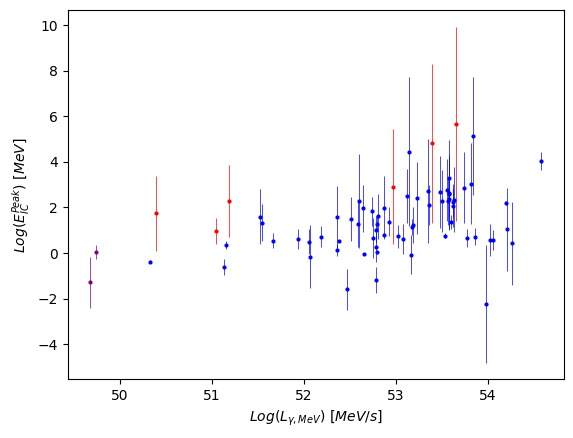

In [24]:
for i in range(len(Matched_JOINED_all)):
    Luminosity = Matched_JOINED_all[i]['Luminosity'].tolist()
    Peak_Energy = [np.log10(float(x)) for x in Matched_JOINED_all[i]['IC_Peak_Energy'].tolist()]
    Peak_Energy_err = [abs(np.log10(float(x))) for x in Matched_JOINED_all[i]['IC_Peak_Energy_err'].tolist()]
    redshift = Matched_JOINED_all[i]['Redshift'].tolist()

    masked_results = [(float(a),b,c,float(d)) for a,b,c,d in zip(Luminosity,Peak_Energy,Peak_Energy_err,redshift) if a != 'None' and d != 'None']

    masked_luminosity, masked_peak_energy, masked_peak_energy_err,masked_redshift = zip(*masked_results)

    masked_luminosity = list(masked_luminosity)
    masked_peak_energy = list(masked_peak_energy)
    masked_peak_energy_err = list(masked_peak_energy_err)

    masked_peak_energy_corr= [x * (1+y) for x,y in zip(masked_peak_energy, masked_redshift)]
    masked_peak_energy_err_corr = [x * (1+y) for x,y in zip(masked_peak_energy_err, masked_redshift)]

    plt.errorbar(masked_luminosity, masked_peak_energy_corr, yerr=masked_peak_energy_err_corr,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(L_{\gamma, MeV})$ $[MeV/s]$')
    plt.ylabel(r'$Log(E^{Peak}_{IC})$ $[MeV]$')

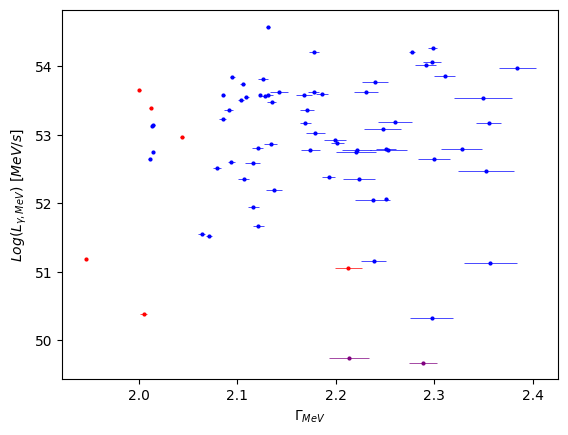

In [25]:
for i in range(len(Matched_JOINED_all)):
    Luminosity = Matched_JOINED_all[i]['Luminosity'].tolist()
    MeV_Index = Matched_JOINED_all[i]['MeV_Index'].tolist()
    MeV_Index_err = Matched_JOINED_all[i]['MeV_Index_err'].tolist()

    masked_results = ((float(a),b,c) for a,b,c in zip(Luminosity,MeV_Index,MeV_Index_err) if a != 'None')

    masked_luminosity,masked_index,masked_index_err = zip(*masked_results)

    masked_luminosity = list(masked_luminosity)
    masked_index = list(masked_index)
    masked_index_err = list(masked_index_err)

    plt.errorbar(masked_index, masked_luminosity, xerr=masked_index_err, fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$\Gamma_{MeV}$')
    plt.ylabel(r'$Log(L_{\gamma, MeV})$ $[MeV/s]$')

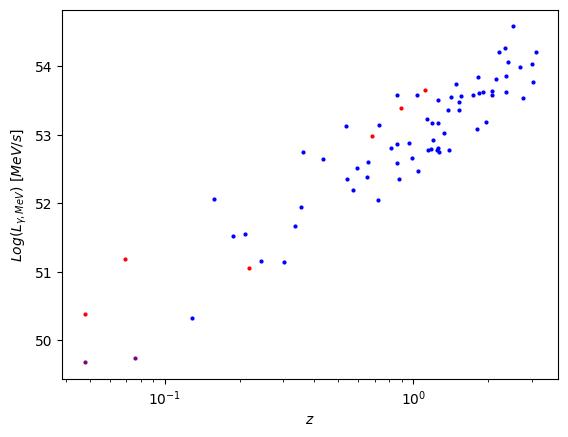

In [26]:
for i in range(len(Matched_JOINED_all)):
    Luminosity = Matched_JOINED_all[i]['Luminosity'].tolist()

    redshift = Matched_JOINED_all[i]['Redshift'].tolist()

    masked_results = [(float(a),float(d)) for a,d in zip(Luminosity,redshift) if a != 'None' and d != 'None']

    masked_luminosity,masked_redshift = zip(*masked_results)

    masked_luminosity = list(masked_luminosity)
    masked_redshift = list(masked_redshift)

    plt.errorbar(masked_redshift, masked_luminosity,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.ylabel(r'$Log(L_{\gamma, MeV})$ $[MeV/s]$')
    plt.xlabel(r'$z$')
    plt.xscale('log')

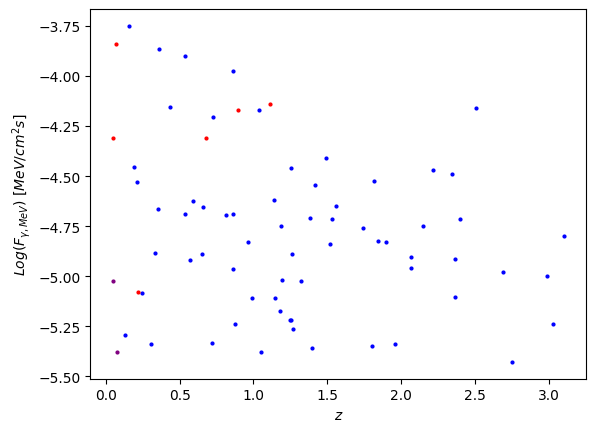

In [27]:
for i in range(len(Matched_JOINED_all)):
    Flux = [np.log10(x) for x in Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()]
    redshift = Matched_JOINED_all[i]['Redshift'].tolist()

    masked_results = [(float(a),float(d)) for a,d in zip(Flux,redshift) if d != 'None']

    masked_flux,masked_redshift = zip(*masked_results)

    masked_flux = list(masked_flux)
    masked_redshift = list(masked_redshift)

    plt.errorbar(masked_redshift, masked_flux,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.ylabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')
    plt.xlabel(r'$z$')
    #plt.xscale('log')

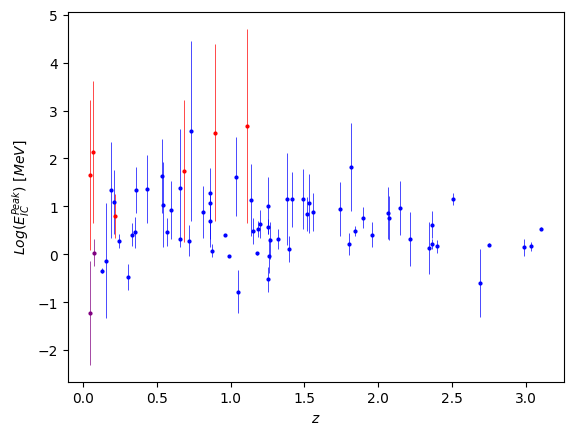

In [28]:
for i in range(len(Matched_JOINED_all)):
    Peak_Energy = [np.log10(float(x)) for x in Matched_JOINED_all[i]['IC_Peak_Energy'].tolist()]
    redshift = Matched_JOINED_all[i]['Redshift'].tolist()
    Peak_Energy_err = [abs(np.log10(float(x))) for x in Matched_JOINED_all[i]['IC_Peak_Energy_err'].tolist()]

    masked_results = [(float(a),b,float(d)) for a,b,d in zip(Peak_Energy,Peak_Energy_err,redshift) if d != 'None']

    masked_peak_energy,masked_peak_energy_err,masked_redshift = zip(*masked_results)

    masked_peak_energy = list(masked_peak_energy)
    masked_redshift = list(masked_redshift)
    masked_peak_energy_err = list(masked_peak_energy_err)

    plt.errorbar(masked_redshift, masked_peak_energy,yerr=masked_peak_energy_err,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.ylabel(r'$Log(E^{Peak}_{IC})$ $[MeV]$')
    plt.xlabel(r'$z$')


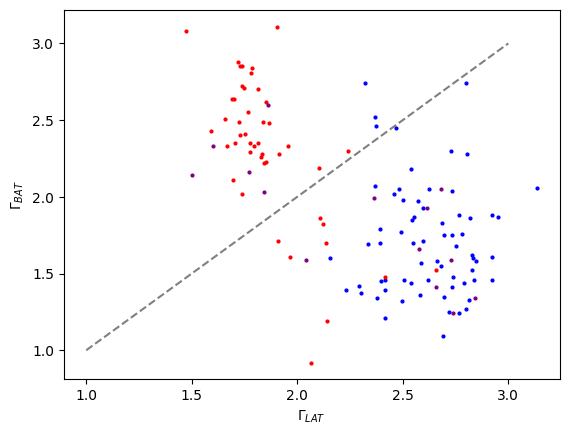

In [29]:
MeV_FSRQ, MeV_BLL, MeV_BCU = mask_catalog_by_class(MeV_Blazar_Catalog, 'Fermi Type')
MeV_Cat_all = [MeV_FSRQ, MeV_BLL, MeV_BCU]

for i in range(len(MeV_Cat_all)):
    Swift_gammas = MeV_Cat_all[i]['Swift Photon Index'].tolist()
    Swift_gammas_err = np.array(MeV_Cat_all[i]['Swift Photon Index Err'].tolist()).T.tolist()
    
    Fermi_gammas = MeV_Cat_all[i]['Fermi Photon Index'].tolist()
    Fermi_gammas_err = MeV_Cat_all[i]['Fermi Photon Index Err'].tolist()

    plt.errorbar(Fermi_gammas, Swift_gammas, fmt='o', markersize=2, elinewidth=0.5, color=colors[i], label=labels[i])
    plt.ylabel(r'$\Gamma_{BAT}$')
    plt.xlabel(r'$\Gamma_{LAT}$')

x = np.linspace(1, 3, 100)
y = x
plt.plot(x, y, linestyle='--', color='grey', label='y = x')

plt.savefig(outdir + 'MeV_Blazar_Catalog_Gamma_comparison.png', bbox_inches='tight')

PKS 1335-127 2.52 2.368502616882324
OG 050 2.46 2.372894287109375
S4 1849+67 2.74 2.321059465408325
S5 1803+784 2.3 2.242063045501709
PKS 0426-380 2.19 2.10367488861084


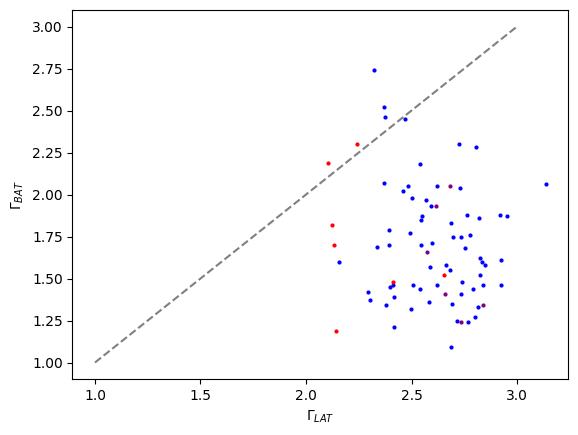

In [30]:
Masked_MeV_FSRQ, Masked_MeV_BLL, Masked_MeV_BCU = mask_catalog_by_class(Masked_MeV_Blazar_Catalog, 'Fermi Type')
Masked_MeV_Cat_all = [Masked_MeV_FSRQ, Masked_MeV_BLL, Masked_MeV_BCU]

for i in range(len(Masked_MeV_Cat_all)):
    Swift_gammas = Masked_MeV_Cat_all[i]['Swift Photon Index'].tolist()
    Swift_gammas_err = np.array(Masked_MeV_Cat_all[i]['Swift Photon Index Err'].tolist()).T.tolist()
    
    Fermi_gammas = Masked_MeV_Cat_all[i]['Fermi Photon Index'].tolist()
    Fermi_gammas_err = Masked_MeV_Cat_all[i]['Fermi Photon Index Err'].tolist()

    for x in range(len(Fermi_gammas)):
        if Swift_gammas[x] - Fermi_gammas[x] > 0:
            print(Masked_MeV_Cat_all[i][x]['Fermi Counterpart Name'], Swift_gammas[x], Fermi_gammas[x])

    plt.errorbar(Fermi_gammas, Swift_gammas, fmt='o', markersize=2, elinewidth=0.5, color=colors[i], label=labels[i])
    plt.ylabel(r'$\Gamma_{BAT}$')
    plt.xlabel(r'$\Gamma_{LAT}$')

x = np.linspace(1, 3, 100)
y = x
plt.plot(x, y, linestyle='--', color='grey', label='y = x')

plt.savefig(outdir + 'Masked_Blazar_Catalog_Gamma_comparison.png', bbox_inches='tight')

# PL Flux

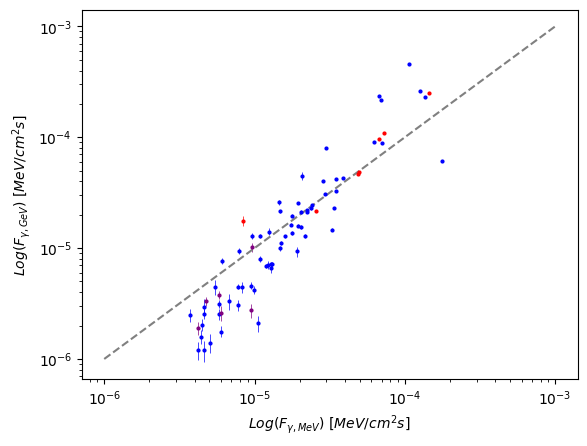

In [31]:
for i in range(len(Matched_JOINED_all)):
    GeV_Flux = Matched_JOINED_all[i]['GeV_Energy_Flux'].tolist()
    GeV_Flux_err = Matched_JOINED_all[i]['GeV_Energy_Flux_err'].tolist()
    MeV_Flux = Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()

    plt.errorbar(MeV_Flux,GeV_Flux,yerr=GeV_Flux_err,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')
    plt.ylabel(r'$Log(F_{\gamma, GeV})$ $[MeV/cm^{2} s]$')
    plt.xscale('log')
    plt.yscale('log')

x = np.linspace(1e-6, 1e-3, 100)
y = x
plt.plot(x, y, linestyle='--', color='grey', label='y = x')

[0.02720587 0.13370719]
[ 0.63100416 -1.7106313 ]


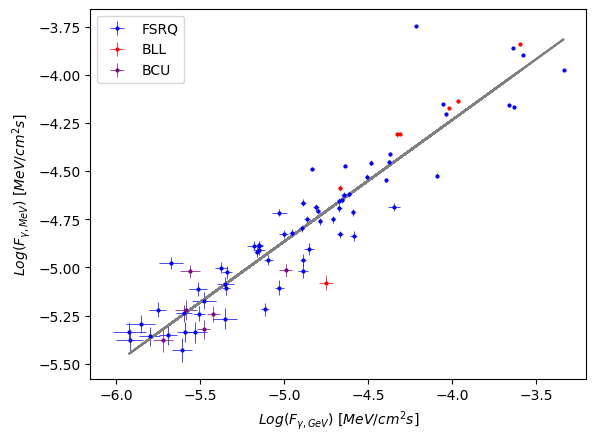

In [32]:
GeV_Flux_all = np.array([np.log10(x) for x in Matched_JOINED_Catalog['GeV_Energy_Flux'].tolist()])
MeV_Flux_all = np.array([np.log10(x) for x in Matched_JOINED_Catalog['MeV_Energy_Flux'].tolist()])

for i in range(len(Matched_JOINED_all)):
    GeV_Flux = Matched_JOINED_all[i]['GeV_Energy_Flux'].tolist()
    GeV_Flux_log = [np.log10(x) for x in Matched_JOINED_all[i]['GeV_Energy_Flux'].tolist()]
    GeV_Flux_err = Matched_JOINED_all[i]['GeV_Energy_Flux_err'].tolist()
    GeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(GeV_Flux_err, GeV_Flux)]

    MeV_Flux = Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()
    MeV_Flux_log = [np.log10(x) for x in Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()]
    MeV_Flux_err = Matched_JOINED_all[i]['MeV_Energy_Flux_err'].tolist()
    MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(MeV_Flux_err, MeV_Flux)]  

    plt.errorbar(GeV_Flux_log,MeV_Flux_log,xerr=GeV_Flux_err_log,yerr=MeV_Flux_err_log,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(F_{\gamma, GeV})$ $[MeV/cm^{2} s]$')
    plt.ylabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')
    #plt.xscale('log')
    #plt.yscale('log')
    plt.legend(loc='upper left')

popt,pcov = curve_fit(line,GeV_Flux_all,MeV_Flux_all, p0=[-6, -5.5])
perr = np.sqrt(np.diag(pcov))
print(perr)

MeV_Flux_slope = popt[0]
MeV_Flux_intercept = popt[1]

plt.plot(GeV_Flux_all, line(GeV_Flux_all,*popt), color = 'grey', linestyle = '-')

print(popt)

plt.savefig(outdir + 'linear_flux_regression.png',bbox_inches='tight')

[-0.29973495  0.29158207]


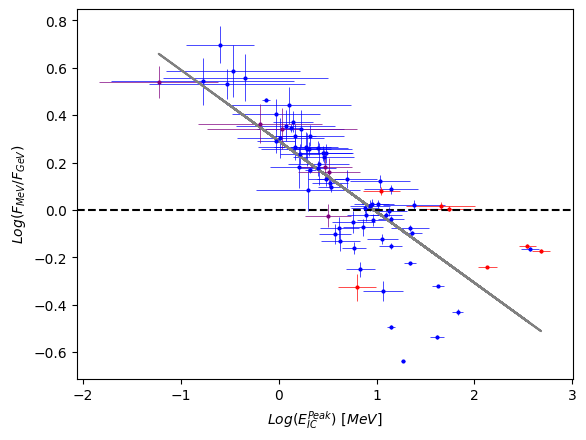

In [33]:
MeV_Flux_all = Matched_JOINED_Catalog['MeV_Energy_Flux'].tolist()
GeV_Flux_all = Matched_JOINED_Catalog['GeV_Energy_Flux'].tolist()
Flux_Ratio_all = np.array([np.log10(x/y) for x,y in zip(MeV_Flux_all, GeV_Flux_all)])
IC_peaks_all = np.array([np.log10(float(x)) for x in Matched_JOINED_Catalog['IC_Peak_Energy'].tolist()])

for i in range(len(Matched_JOINED_all)):
    GeV_Flux = Matched_JOINED_all[i]['GeV_Energy_Flux'].tolist()
    GeV_Flux_err = Matched_JOINED_all[i]['GeV_Energy_Flux_err'].tolist()

    MeV_Flux = Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()
    MeV_Flux_err = Matched_JOINED_all[i]['MeV_Energy_Flux_err'].tolist()

    Flux_Ratio = [np.log10(x/y) for x,y in zip(MeV_Flux, GeV_Flux)]
    Flux_Ratio_err = [(np.sqrt((A_err / A)**2 + (B_err / B)**2) / np.log(10)) for A,A_err,B,B_err in zip(MeV_Flux,MeV_Flux_err,GeV_Flux,GeV_Flux_err)]
    
    IC_peak_energy = [float(x) for x in Matched_JOINED_all[i]['IC_Peak_Energy'].tolist()]
    IC_peak_energy_log = [np.log10(float(x)) for x in IC_peak_energy]
    IC_peak_energy_err = [(float(x)) for x in Matched_JOINED_all[i]['IC_Peak_Energy_err'].tolist()]
    IC_peak_energy_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(IC_peak_energy_err, IC_peak_energy)]

    plt.errorbar(IC_peak_energy_log,Flux_Ratio,xerr=IC_peak_energy_err_log,yerr=Flux_Ratio_err,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.ylabel(r'$Log(F_{MeV}/F_{GeV})$')
    plt.xlabel(r'$Log(E_{IC}^{Peak})$ $[MeV]$')

popt,pcov = curve_fit(line,IC_peaks_all,Flux_Ratio_all, p0=[-1,0.8])
plt.plot(IC_peaks_all, line(IC_peaks_all,*popt), color = 'grey', linestyle = '-')
print(popt)

plt.axhline(y=0,linestyle='--',color='black')

plt.savefig(outdir + 'Flux_ratio_peak_energy.png',bbox_inches='tight')


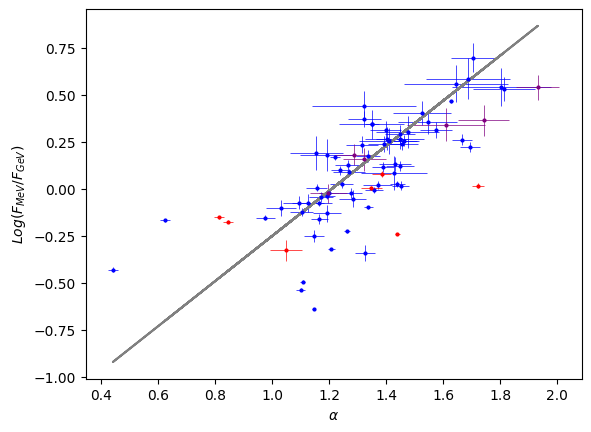

In [34]:
Alpha_all = np.array(Matched_JOINED_Catalog['Alpha'].tolist())

for i in range(len(Matched_JOINED_all)):
    GeV_Flux = Matched_JOINED_all[i]['GeV_Energy_Flux'].tolist()
    GeV_Flux_err = Matched_JOINED_all[i]['GeV_Energy_Flux_err'].tolist()

    MeV_Flux = Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()
    MeV_Flux_err = Matched_JOINED_all[i]['MeV_Energy_Flux_err'].tolist()
    

    Flux_Ratio = [np.log10(x/y) for x,y in zip(MeV_Flux, GeV_Flux)]
    Flux_Ratio_err = [(np.sqrt((A_err / A)**2 + (B_err / B)**2) / np.log(10)) for A,A_err,B,B_err in zip(MeV_Flux,MeV_Flux_err,GeV_Flux,GeV_Flux_err)]

    Alpha = Matched_JOINED_all[i]['Alpha'].tolist()
    Alpha_err = Matched_JOINED_all[i]['Alpha_err'].tolist()

    plt.errorbar(Alpha,Flux_Ratio,xerr=Alpha_err,yerr=Flux_Ratio_err,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$\alpha$')
    plt.ylabel(r'$Log(F_{MeV}/F_{GeV})$')

plt.plot(Alpha_all, line(Alpha_all,*[1.2,-1.45]), color = 'grey', linestyle = '-')

plt.savefig(outdir + 'flux_ratio_alphas.png',bbox_inches='tight')

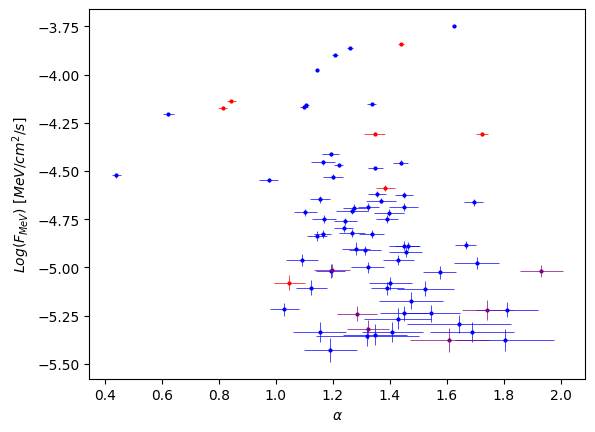

In [35]:
for i in range(len(Matched_JOINED_all)):
    MeV_Flux = Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()
    MeV_Flux_log = [np.log10(x) for x in Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()]
    MeV_Flux_err = Matched_JOINED_all[i]['MeV_Energy_Flux_err'].tolist()
    MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(MeV_Flux_err, MeV_Flux)] 

    Alpha = Matched_JOINED_all[i]['Alpha'].tolist()
    Alpha_err = Matched_JOINED_all[i]['Alpha_err'].tolist()

    plt.errorbar(Alpha,MeV_Flux_log,xerr=Alpha_err,yerr=MeV_Flux_err_log,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$\alpha$')
    plt.ylabel(r'$Log(F_{MeV})$ $[MeV/cm^{2}/s]$')

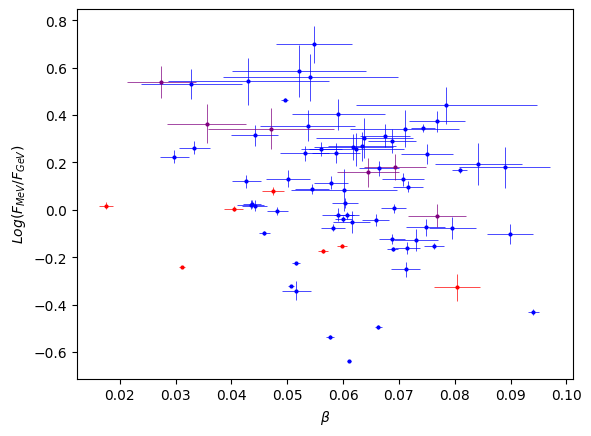

In [36]:
for i in range(len(Matched_JOINED_all)):
    GeV_Flux = Matched_JOINED_all[i]['GeV_Energy_Flux'].tolist()
    GeV_Flux_err = Matched_JOINED_all[i]['GeV_Energy_Flux_err'].tolist()

    MeV_Flux = Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()
    MeV_Flux_err = Matched_JOINED_all[i]['MeV_Energy_Flux_err'].tolist()
    

    Flux_Ratio = [np.log10(x/y) for x,y in zip(MeV_Flux, GeV_Flux)]
    Flux_Ratio_err = [(np.sqrt((A_err / A)**2 + (B_err / B)**2) / np.log(10)) for A,A_err,B,B_err in zip(MeV_Flux,MeV_Flux_err,GeV_Flux,GeV_Flux_err)]

    Beta = Matched_JOINED_all[i]['Beta'].tolist()
    Beta_err = Matched_JOINED_all[i]['Beta_err'].tolist()

    plt.errorbar(Beta,Flux_Ratio,xerr=Beta_err,yerr=Flux_Ratio_err,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$\beta$')
    plt.ylabel(r'$Log(F_{MeV}/F_{GeV})$')


# Log Parabola Flux

In [37]:
LP_Flux_fitting_results

Name,Class,Alpha,Alpha_Err,Beta,Beta_Err,Energy_Flux,Energy_Flux_Err,Photon_Flux,Photon_Flux_Err,Chi2
,,,,,,MeV / (s cm2),MeV / (s cm2),1 / (s cm2),1 / (s cm2),
bytes23,bytes4,float64,float64,float64,float64,float64,float64,float64,float64,float64
B2 0135+291,bcu,1.609408258968218,0.1493769028194322,0.04708853152062286,0.01216604596557013,1.3765729419156577e-05,3.843832214073633e-06,2.1566456875912628e-05,5.208396426499597e-06,0.0018688826042658163
PKS 0142-278,fsrq,1.3916876902353617,0.057348775700480484,0.05871691961080475,0.004286978997936957,3.105076491351884e-05,3.201144012540428e-06,3.8073081629604815e-05,4.653306822819325e-06,0.0012019256779257684
PKS 0202-17,fsrq,1.2434086422613426,0.0402202365864971,0.06040048571996615,0.0023561404121553646,6.22890591416455e-05,4.053229961399394e-06,5.559227681428192e-05,5.881726651330873e-06,0.004974980074364466
S5 0212+73,fsrq,1.3136013875894623,0.05593029458358471,0.07508475388952342,0.0047018810946067476,0.00010755536739962638,1.108616651590699e-05,0.00015286838103414094,1.1791774569833004e-05,0.0013180022966608682
PKS 0240-060,fsrq,1.3483770012117107,0.11381504289809038,0.07102335662278082,0.009789969382156979,2.8563402222706047e-05,5.761740373349784e-06,4.0494678316680334e-05,7.17456558085598e-06,0.0011140926909628754
4C +33.06,bcu,1.7424417845271227,0.09411649615762992,0.03555202379339568,0.007507370199810622,1.6163264891282616e-05,3.157207163369012e-06,2.698510957362819e-05,4.570697101583045e-06,0.0005519563327006325
TXS 0322+222,fsrq,1.0927303627631548,0.05621505505191063,0.07485110246327789,0.003484516259848698,7.18570575570221e-05,6.5423775441039454e-06,6.196856750394493e-05,8.5189938226218e-06,0.002770376780643395
NRAO 150,fsrq,1.1447796811536612,0.03530234108349035,0.07128305402463836,0.002607589258827773,0.00013937263067221667,8.892287680301483e-06,0.0001257069858888544,8.428594273322182e-06,0.0011114440932340369


In [38]:
LP_Flux_Fit_FSRQ, LP_Flux_Fit_BLL, LP_Flux_Fit_BCU = mask_catalog_by_class(LP_Flux_fitting_results, 'Class')
LP_Flux_Fit_all = [LP_Flux_Fit_FSRQ, LP_Flux_Fit_BLL, LP_Flux_Fit_BCU]

PL_Flux_Fit_FSRQ, PL_Flux_Fit_BLL, PL_Flux_Fit_BCU = mask_catalog_by_class(PL_Flux_fitting_results, 'Class')
PL_Flux_Fit_all = [PL_Flux_Fit_FSRQ, PL_Flux_Fit_BLL, PL_Flux_Fit_BCU]

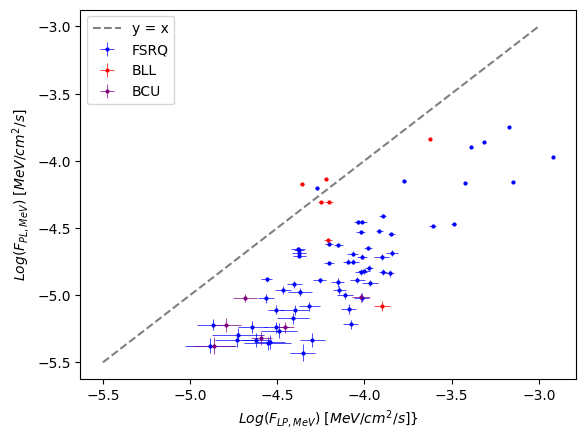

In [39]:

for i in range(len(LP_Flux_Fit_all)):
    LP_MeV_Flux = LP_Flux_Fit_all[i]['Energy_Flux'].tolist()
    LP_MeV_Flux_err = LP_Flux_Fit_all[i]['Energy_Flux_Err'].tolist()
    LP_MeV_Flux_log = [np.log10(x) for x in LP_MeV_Flux]
    LP_MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(LP_MeV_Flux_err, LP_MeV_Flux)]

    MeV_Flux = Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()
    MeV_Flux_log = [np.log10(x) for x in Matched_JOINED_all[i]['MeV_Energy_Flux'].tolist()]
    MeV_Flux_err = Matched_JOINED_all[i]['MeV_Energy_Flux_err'].tolist()
    MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(MeV_Flux_err, MeV_Flux)]  

    plt.errorbar(LP_MeV_Flux_log, MeV_Flux_log, xerr=LP_MeV_Flux_err_log, yerr=MeV_Flux_err_log, fmt='o', markersize=2, color=colors[i], label=labels[i], elinewidth=0.5)
    plt.xlabel(r'$Log(F_{LP, MeV})$ $[MeV/cm^{2}/s]$}')
    plt.ylabel(r'$Log(F_{PL, MeV})$ $[MeV/cm^{2}/s]$')

x = np.linspace(-5.5, -3, 100)
y = x
plt.plot(x, y, linestyle='--', color='grey', label='y = x')
plt.legend(loc='upper left')

plt.savefig(outdir + 'LP_vs_PL_fluxes.png', bbox_inches='tight')

4C +71.07
3C 273
3C 279
PKS 1510-089
PKS 1830-211
PKS 2149-306
CTA 102
3C 454.3
BL Lac
[ 0.52579267 -1.59396079]


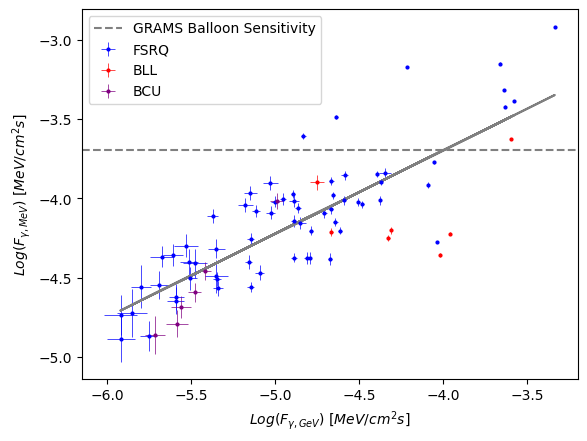

In [40]:
GeV_Flux_all = np.array([np.log10(x) for x in Matched_JOINED_Catalog['GeV_Energy_Flux'].tolist()])
MeV_Flux_all = np.array([np.log10(x) for x in LP_Flux_fitting_results['Energy_Flux'].tolist()])

for i in range(len(Matched_JOINED_all)):
    GeV_Flux = Matched_JOINED_all[i]['GeV_Energy_Flux'].tolist()
    GeV_Flux_log = [np.log10(x) for x in Matched_JOINED_all[i]['GeV_Energy_Flux'].tolist()]
    GeV_Flux_err = Matched_JOINED_all[i]['GeV_Energy_Flux_err'].tolist()
    GeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(GeV_Flux_err, GeV_Flux)]

    LP_MeV_Flux = LP_Flux_Fit_all[i]['Energy_Flux'].tolist()
    LP_MeV_Flux_err = LP_Flux_Fit_all[i]['Energy_Flux_Err'].tolist()
    LP_MeV_Flux_log = [np.log10(x) for x in LP_MeV_Flux]
    LP_MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(LP_MeV_Flux_err, LP_MeV_Flux)]

    for x in range(len(LP_MeV_Flux_log)):
        if LP_MeV_Flux_log[x] > -3.6925:
            print(Matched_JOINED_all[i][x]['Name'])

    plt.errorbar(GeV_Flux_log,LP_MeV_Flux_log,xerr=GeV_Flux_err_log,yerr=LP_MeV_Flux_err_log,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(F_{\gamma, GeV})$ $[MeV/cm^{2} s]$')
    plt.ylabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')
    #plt.xscale('log')
    #plt.yscale('log')
    plt.legend(loc='upper left')

plt.axhline(y=-3.6925,linestyle='--',color='grey', label='GRAMS Balloon Sensitivity')
plt.legend()

popt,pcov = curve_fit(line,GeV_Flux_all,MeV_Flux_all, p0=[-6, -5.5])
plt.plot(GeV_Flux_all, line(GeV_Flux_all,*popt), color = 'grey', linestyle = '-')
print(popt)

plt.savefig(outdir + 'LP_MeV_vs_GeV_fluxes.png', bbox_inches='tight')

[-0.46220646  1.0313626 ]


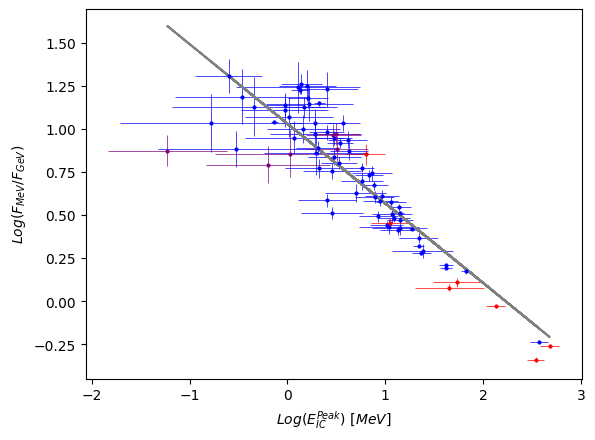

In [41]:
MeV_Flux_all = LP_Flux_fitting_results['Energy_Flux'].tolist()
GeV_Flux_all = Matched_JOINED_Catalog['GeV_Energy_Flux'].tolist()
Flux_Ratio_all = np.array([np.log10(x/y) for x,y in zip(MeV_Flux_all, GeV_Flux_all)])
IC_peaks_all = np.array([np.log10(float(x)) for x in Matched_JOINED_Catalog['IC_Peak_Energy'].tolist()])

for i in range(len(Matched_JOINED_all)):
    GeV_Flux = Matched_JOINED_all[i]['GeV_Energy_Flux'].tolist()
    GeV_Flux_err = Matched_JOINED_all[i]['GeV_Energy_Flux_err'].tolist()

    LP_MeV_Flux = LP_Flux_Fit_all[i]['Energy_Flux'].tolist()
    LP_MeV_Flux_err = LP_Flux_Fit_all[i]['Energy_Flux_Err'].tolist()

    Flux_Ratio = [np.log10(x/y) for x,y in zip(LP_MeV_Flux, GeV_Flux)]
    Flux_Ratio_err = [(np.sqrt((A_err / A)**2 + (B_err / B)**2) / np.log(10)) for A,A_err,B,B_err in zip(LP_MeV_Flux,LP_MeV_Flux_err,GeV_Flux,GeV_Flux_err)]
    
    IC_peak_energy = [float(x) for x in Matched_JOINED_all[i]['IC_Peak_Energy'].tolist()]
    IC_peak_energy_log = [np.log10(float(x)) for x in IC_peak_energy]
    IC_peak_energy_err = [(float(x)) for x in Matched_JOINED_all[i]['IC_Peak_Energy_err'].tolist()]
    IC_peak_energy_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(IC_peak_energy_err, IC_peak_energy)]

    plt.errorbar(IC_peak_energy_log,Flux_Ratio,xerr=IC_peak_energy_err_log,yerr=Flux_Ratio_err,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.ylabel(r'$Log(F_{MeV}/F_{GeV})$')
    plt.xlabel(r'$Log(E_{IC}^{Peak})$ $[MeV]$')

popt,pcov = curve_fit(line,IC_peaks_all,Flux_Ratio_all, p0=[-1,0.8])
plt.plot(IC_peaks_all, line(IC_peaks_all,*popt), color = 'grey', linestyle = '-')
print(popt)

plt.savefig(outdir + 'Flux_ratio_peak_energy_LP.png',bbox_inches='tight')


# Comparison of Spectral Models

B2 0743+25
S5 1039+81
3C 273
3C 454.3
PKS 0607-549
['PKS 0142-278', 'PKS 0202-17', 'S5 0212+73', 'PKS 0240-060', 'TXS 0322+222', 'NRAO 150', 'PKS 0454-46', 'PKS 0528+134', 'PKS 0537-286', 'B2 0552+39A', 'PKS 0637-75', 'PMN J0641-0320', 'PKS 0736+01', 'B2 0743+25', 'TXS 0800+618', '4C +71.07', '4C +40.24', 'PMN J0957-1350', 'S5 1039+81', 'PKS 1127-14', 'PKS 1143-696', 'B2 1150+33A', '4C +49.22', 'Ton 599', '4C +04.42', '4C +21.35', '3C 273', 'ON 187', '3C 279', 'PKS 1329-049', '4C +19.44', 'PKS 1510-089', '4C +38.41', '3C 345', '2MASS J16561677-3302127', 'PKS 1824-582', 'PKS 1830-211', 'PKS B1921-293', 'MG2 J201534+3710', 'OX 169', 'PKS 2142-75', 'PKS 2149-306', 'NRAO 676', 'PKS 2223+21', 'PKS 2227-08', 'CTA 102', '3C 454.3', 'PKS 2325+093', 'PKS 2145+06', '4C +06.41', 'OG 050', '4C +73.18', 'NRAO 140', 'TXS 0222+185', 'RX J062308.0-643619', 'PKS 2008-159', 'PKS 0834-20', 'MG4 J162551+4346', 'PKS 0537-441', 'AP Librae', 'PKS 1936-623', 'BL Lac', 'B2 2023+33', 'B2 0135+291', '4C +33.06',

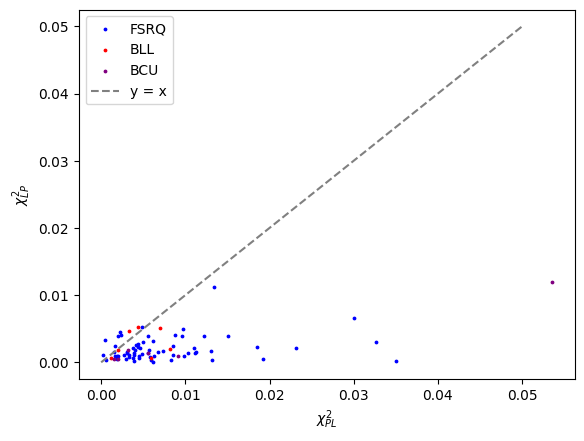

In [42]:
Log_parabola_names = []
Power_Law_names = []

for i in range(len(PL_Flux_Fit_all)):
    chi2_PL = PL_Flux_Fit_all[i]['Chi2'].tolist()
    chi2_LP = LP_Flux_Fit_all[i]['Chi2'].tolist()

    for x in range(len(chi2_PL)):
        if chi2_PL[x] > chi2_LP[x]:
            Log_parabola_names.append(PL_Flux_Fit_all[i][x]['Name'])
        elif chi2_PL[x] < chi2_LP[x]:
            Power_Law_names.append(LP_Flux_Fit_all[i][x]['Name'])

        if chi2_PL[x] - chi2_LP[x] > 0.02:
            print(LP_Flux_Fit_all[i][x]['Name'])
        

    plt.scatter(chi2_PL, chi2_LP, color=colors[i], label=labels[i], s=3)
    plt.xlabel(r'$\chi^2_{PL}$')
    plt.ylabel(r'$\chi^2_{LP}$')

    plt.legend()

x = np.linspace(0, 0.05, 100)
y = x
plt.plot(x, y, linestyle='--', color='grey', label='y = x')
plt.legend()

plt.savefig(outdir + 'Chi2_comparison.png', bbox_inches='tight')

print(Log_parabola_names)
print(len(Log_parabola_names))
print(Power_Law_names)
print(len(Power_Law_names))

In [43]:
Masked_matched_names = [x.ljust(28) for x in Masked_Flux_fitting_results['Name'].tolist()]
name_mask = [x in Masked_matched_names for x in Fermi_LAT_DR4['ASSOC1'].tolist()]
Fermi_LAT_DR4_masked = Fermi_LAT_DR4[name_mask]
#Fermi_LAT_DR4_masked.pprint_all()

print('Log Parabola Sources:')
print(' ')

for i in range(len(Log_parabola_names)):
    mask = (Log_parabola_names[i].ljust(28) == Fermi_LAT_DR4_masked['ASSOC1'])
    SED_fit_type = Fermi_LAT_DR4_masked[mask]['SpectrumType'].tolist()[0].strip(' ')
    print(Log_parabola_names[i], SED_fit_type)

print(' ')
print('Power Law Sources:')
print(' ')

for i in range(len(Power_Law_names)):
    mask = (Power_Law_names[i].ljust(28) == Fermi_LAT_DR4_masked['ASSOC1'])
    SED_fit_type = Fermi_LAT_DR4_masked[mask]['SpectrumType'].tolist()[0].strip(' ')
    print(Power_Law_names[i], SED_fit_type)

Log Parabola Sources:
 
PKS 0142-278 LogParabola
PKS 0202-17 LogParabola
S5 0212+73 LogParabola
PKS 0240-060 PowerLaw
TXS 0322+222 LogParabola
NRAO 150 LogParabola
PKS 0454-46 LogParabola
PKS 0528+134 LogParabola
PKS 0537-286 LogParabola
B2 0552+39A LogParabola
PKS 0637-75 LogParabola
PMN J0641-0320 LogParabola
PKS 0736+01 LogParabola
B2 0743+25 LogParabola
TXS 0800+618 LogParabola
4C +71.07 LogParabola
4C +40.24 PowerLaw
PMN J0957-1350 LogParabola
S5 1039+81 LogParabola
PKS 1127-14 LogParabola
PKS 1143-696 LogParabola
B2 1150+33A PowerLaw
4C +49.22 LogParabola
Ton 599 LogParabola
4C +04.42 LogParabola
4C +21.35 LogParabola
3C 273 LogParabola
ON 187 PowerLaw
3C 279 PLSuperExpCutoff
PKS 1329-049 LogParabola
4C +19.44 PowerLaw
PKS 1510-089 LogParabola
4C +38.41 LogParabola
3C 345 LogParabola
2MASS J16561677-3302127 LogParabola
PKS 1824-582 LogParabola
PKS 1830-211 LogParabola
PKS B1921-293 LogParabola
MG2 J201534+3710 LogParabola
OX 169 LogParabola
PKS 2142-75 LogParabola
PKS 2149-306 Lo

# Binned Correlation Plot

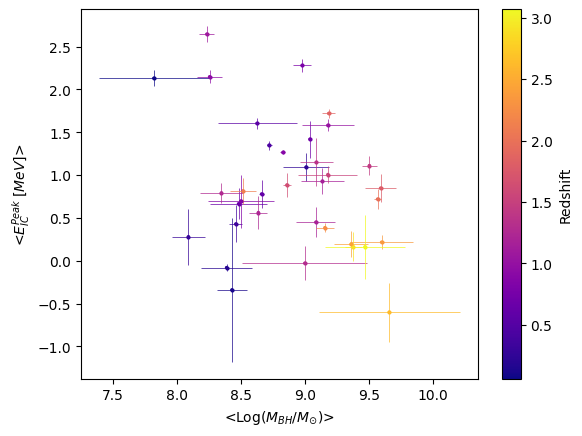

In [51]:
Redshift_mask = (Matched_JOINED_Catalog['Redshift'] != 'None')
Matched_Redshift_list = [float(x) for x in Matched_JOINED_Catalog[Redshift_mask]['Redshift'].tolist()]

num_bins =36

Matched_bin_bounds = make_bin_bounds(Matched_Redshift_list,num_bins)

binned_mass = [[] for _ in range(len(Matched_bin_bounds) - 1)]
binned_IC_peak = [[] for _ in range(len(Matched_bin_bounds) - 1)]
binned_mass_err = [[] for _ in range(len(Matched_bin_bounds) - 1)]
binned_IC_peak_err = [[] for _ in range(len(Matched_bin_bounds) - 1)]


for i in range(len(Matched_JOINED_Catalog)):
    if Matched_JOINED_Catalog[i]['Redshift'] != 'None' and Matched_JOINED_Catalog[i]['BH_Mass'] != 'None':
        Mass = float(Matched_JOINED_Catalog[i]['BH_Mass'])
        Mass_err = float(Matched_JOINED_Catalog[i]['BH_Mass_err'])
        Redshift = float(Matched_JOINED_Catalog[i]['Redshift'])
        IC_peak_energy = float(Matched_JOINED_Catalog[i]['IC_Peak_Energy'])
        IC_peak_energy_log = np.log10(IC_peak_energy)
        IC_peak_energy_err = float(Matched_JOINED_Catalog[i]['IC_Peak_Energy_err'])
        IC_peak_energy_err_log = abs((1/np.log(10)) * (IC_peak_energy_err/IC_peak_energy))

        for z in range(len(Matched_bin_bounds) - 1):
            if Matched_bin_bounds[z] <= Redshift < Matched_bin_bounds[z+1]:
                binned_mass[z].append(Mass)
                binned_IC_peak[z].append(IC_peak_energy_log)
                binned_mass_err[z].append(Mass_err)
                binned_IC_peak_err[z].append(IC_peak_energy_err_log)

redshift_bin_centers = np.array([(Matched_bin_bounds[x] + Matched_bin_bounds[x+1])/2 for x in range(len(Matched_bin_bounds) - 1)])


weighted_mass = []
weighted_mass_err = []
weighted_peak_energy = []
weighted_peak_energy_err = []

for i in range(len(binned_mass)):

    color=plt.cm.plasma((redshift_bin_centers[i] - redshift_bin_centers.min()) / (redshift_bin_centers.max() - redshift_bin_centers.min()))

    weighted_binned_mass_avg, weighted_binned_mass_avg_err = weighted_avg_and_err(binned_mass[i],binned_mass_err[i])
    weighted_binned_IC_peak_avg, weighted_binned_IC_peak_avg_err = weighted_avg_and_err(binned_IC_peak[i], binned_IC_peak_err[i])

    weighted_mass.append(weighted_binned_mass_avg)
    weighted_mass_err.append(weighted_binned_mass_avg_err)
    weighted_peak_energy.append(weighted_binned_IC_peak_avg)
    weighted_peak_energy_err.append(weighted_binned_IC_peak_avg_err)

    plt.errorbar(weighted_binned_mass_avg, weighted_binned_IC_peak_avg, xerr=weighted_binned_mass_avg_err, yerr=weighted_binned_IC_peak_avg_err, fmt='o', color=color,markersize=2,elinewidth=0.5)
    plt.xlabel(r'<Log(${M_{BH}}$/$M_{\odot}$)>')
    plt.ylabel(r'<$E^{Peak}_{IC}$ $[MeV]$>')
    


sc = plt.scatter(weighted_mass, weighted_peak_energy, c=redshift_bin_centers, cmap='plasma',s=2)
cbar = plt.colorbar(sc, label='Redshift')

plt.savefig(outdir + 'Binned_averages_matched_catalog.png',bbox_inches='tight')

# Expanded Catalog Calculations

4C +01.02
PKS 0346-27
PKS 0454-234
3C 279
PKS 1424-41
PKS 1502+106
PKS 1510-089
PKS 1830-211
CTA 102
3C 454.3
PKS 0426-380
PKS 0537-441
BL Lac


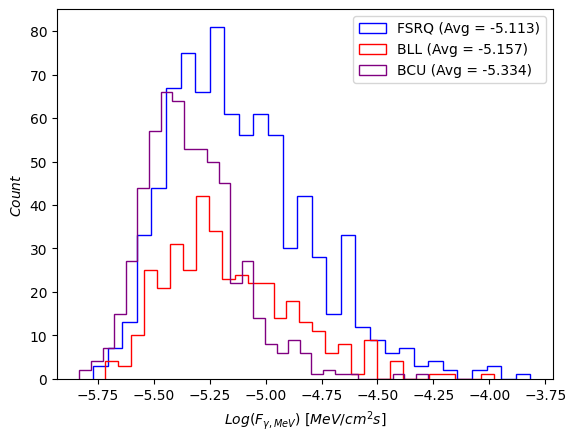

In [45]:
Masked_LAT_FSRQ,Masked_LAT_BLL,Masked_LAT_BCU = mask_catalog_by_class(Masked_LAT_data, 'Class')
Masked_LAT_all = [Masked_LAT_FSRQ,Masked_LAT_BLL,Masked_LAT_BCU]

for i in range(len(Masked_LAT_all)):
    GeV_Flux = [np.log10(x) for x in Masked_LAT_all[i]['Energy_Flux_GeV'].tolist()]
    MeV_Flux = [MeV_Flux_slope * x + MeV_Flux_intercept for x in GeV_Flux]

    for x in range(len(MeV_Flux)):
        if MeV_Flux[x] >= -4.25:
            print(Masked_LAT_all[i][x]['Assoc_Name'])

    MeV_flux_mean = round(np.mean(MeV_Flux),3)

    plt.hist(MeV_Flux, 30, histtype='step',color=colors[i],label=f"{labels[i]} (Avg = {MeV_flux_mean})")
    plt.xlabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')
    plt.ylabel(r'$Count$')
    plt.legend(loc='upper right')

plt.savefig(outdir + 'MeV_Flux_Estimates.png', bbox_inches='tight')
    

4.313000202178955


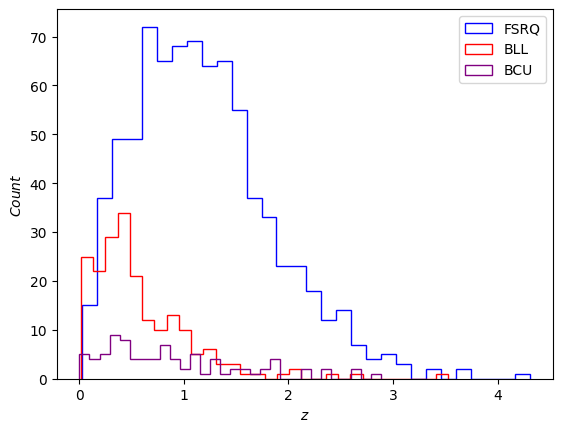

In [46]:
for i in range(len(Masked_LAT_all)):
    Redshift = Masked_LAT_all[i]['Redshift'].tolist()
    Redshift_known = [float(x) for x in Redshift if x != 'None']

    for x in range(len(Redshift_known)):
        if Redshift_known[x] >= 4:
            print(Redshift_known[x])

    num_bins = 30

    plt.hist(Redshift_known, num_bins, histtype='step',color=colors[i],label=f"{labels[i]}")
    plt.xlabel(r'$z$')
    plt.ylabel(r'$Count$')
    plt.legend(loc='upper right')